# Análisis Exploratorio de Datos (EDA) — Flujo de Viajeros por Fronteras

Este notebook realiza un análisis exploratorio sobre un conjunto de datos de viajeros con las siguientes variables:

- `Frontera`
- `País`
- `Región`
- `Región dos`
- `Regiones OMT`
- `MCEO`
- `Agrupación Residencia`
- `Tipo de Viajero`
- `Viajero`

**Cobertura del análisis:**
1. Comportamiento temporal del número de viajeros
2. Países con mayor cantidad de viajeros
3. Regiones con mayor cantidad de viajeros
4. Vías de ingreso y fronteras más utilizadas
5. Valores faltantes, duplicados y valores atípicos
6. Estadísticas descriptivas, visualizaciones e interpretación

> **Nota:** El dataset no incluye explícitamente una columna de fecha en la lista de variables proporcionada.
> El notebook detecta automáticamente columnas de fecha/año/mes comunes (`Fecha`, `Año`, `Mes`, `Periodo`, `Year`, `Month`).
> Si tu archivo usa otro nombre, ajusta la variable `DATE_COL` (o `YEAR_COL`/`MONTH_COL`) en la sección de configuración.


## 1. Configuración e importación de librerías

In [1]:
# Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)


In [2]:
# ------------------ CONFIGURACIÓN ------------------
FILE_PATH = "data/Base_Migracion_2009-2026jun.xlsx"
SHEET_NAME = "Datos"

# Columna(s) temporal(es).
DATE_COL = None      # ej. "Fecha"
YEAR_COL = None      # ej. "Año"
MONTH_COL = None     # ej. "Mes cod"

# Nombres candidatos por si quieres detección automática.
# "Mes cod" va primero porque es numérico (1-12); "Mes" es el nombre en español
# (Ene, Feb, ...) y no lo interpreta pd.to_datetime, así que solo se usa como respaldo.
CANDIDATE_DATE_COLS = ["Fecha", "fecha", "Date", "Periodo", "PERIODO"]
CANDIDATE_YEAR_COLS = ["Año", "Anio", "Year", "AÑO", "ANIO"]
CANDIDATE_MONTH_COLS = ["Mes cod", "Mes", "Month", "MES"]

# Columna numérica objetivo: "Viajero" es la CANTIDAD de viajeros para esa combinación
# de Año/Mes/Vía/Frontera/País/Tipo de Viajero (no es una fila por viajero individual).
# Por eso todas las agregaciones de este notebook usan sum(VIAJEROS_COL), nunca
# conteo de filas (size()/value_counts()), que subestimaría los volúmenes reales.
VIAJEROS_COL = "Viajero"


## 2. Carga de datos

In [3]:
def cargar_datos(path, sheet_name=None):
    path = Path(path)
    if path.suffix.lower() in [".xlsx", ".xls"]:
        return pd.read_excel(path, sheet_name=sheet_name) if sheet_name else pd.read_excel(path)
    return pd.read_csv(path, encoding="utf-8-sig")

df = cargar_datos(FILE_PATH, SHEET_NAME)
df.columns = [c.strip() for c in df.columns]
print(f"Dimensiones del dataset: {df.shape[0]:,} filas x {df.shape[1]} columnas")
df.head()


Dimensiones del dataset: 161,036 filas x 13 columnas


,Año,Mes cod,Mes,Vía,Frontera,País,Región,Región dos,Regiones OMT,MCEO,Agrupación Residencia,Tipo de Viajero,Viajero
0,2009,1,Ene,Aérea,01 La Aurora,Albania,OTROS EUROPEOS,Europa,EUROPA MERIDIONAL,08 OTROS,Europa,Turista,1.0
1,2009,1,Ene,Aérea,01 La Aurora,Alemania,EUROPA,Europa,EUROPA OCCIDENTAL,04 EUROPA,Europa,Turista,716.0
2,2009,1,Ene,Aérea,01 La Aurora,Angola,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA CENTRAL,08 OTROS,Resto del Mundo,Turista,4.0
3,2009,1,Ene,Aérea,01 La Aurora,Arabia Saudita,OTROS ORIENTE MEDIO,Oriente Medio,ORIENTE MEDIO,08 OTROS,Resto del Mundo,Turista,5.0
4,2009,1,Ene,Aérea,01 La Aurora,Argelia,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA DEL NORTE,08 OTROS,Resto del Mundo,Turista,1.0


In [4]:
# Detección automática de columnas temporales si no se configuraron manualmente
if DATE_COL is None:
    for c in CANDIDATE_DATE_COLS:
        if c in df.columns:
            DATE_COL = c
            break

if DATE_COL is None and YEAR_COL is None:
    for c in CANDIDATE_YEAR_COLS:
        if c in df.columns:
            YEAR_COL = c
            break
    for c in CANDIDATE_MONTH_COLS:
        if c in df.columns:
            MONTH_COL = c
            break

print("DATE_COL detectada:", DATE_COL)
print("YEAR_COL detectada:", YEAR_COL)
print("MONTH_COL detectada:", MONTH_COL)

if DATE_COL is None and YEAR_COL is None:
    print("\n⚠️  No se encontró columna temporal. Define DATE_COL o YEAR_COL/MONTH_COL "
          "manualmente en la sección de configuración para habilitar el análisis temporal.")


DATE_COL detectada: None
YEAR_COL detectada: Año
MONTH_COL detectada: Mes cod


In [5]:
# Construcción de una columna de fecha estandarizada 'fecha_dt' cuando sea posible
if DATE_COL is not None:
    df["fecha_dt"] = pd.to_datetime(df[DATE_COL], errors="coerce")
elif YEAR_COL is not None:
    if MONTH_COL is not None:
        df["fecha_dt"] = pd.to_datetime(
            df[YEAR_COL].astype(str) + "-" + df[MONTH_COL].astype(str) + "-01",
            errors="coerce"
        )
    else:
        df["fecha_dt"] = pd.to_datetime(df[YEAR_COL].astype(str) + "-01-01", errors="coerce")
else:
    df["fecha_dt"] = pd.NaT


## 3. Vista general del dataset

Tipos de dato, memoria utilizada y primeras/últimas observaciones.

In [6]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 161036 entries, 0 to 161035
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Año                    161036 non-null  int64         
 1   Mes cod                161036 non-null  int64         
 2   Mes                    161036 non-null  str           
 3   Vía                    161036 non-null  str           
 4   Frontera               161036 non-null  str           
 5   País                   161036 non-null  str           
 6   Región                 161036 non-null  str           
 7   Región dos             161036 non-null  str           
 8   Regiones OMT           161036 non-null  str           
 9   MCEO                   161036 non-null  str           
 10  Agrupación Residencia  161036 non-null  str           
 11  Tipo de Viajero        161036 non-null  str           
 12  Viajero                161036 non-null  float64       


In [7]:
df.describe(include="all").transpose()


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Año,161036.0,NaN,NaN,NaN,2016.017543,2009.0,2012.0,2016.0,2019.0,2026.0,4.552887
Mes cod,161036.0,NaN,NaN,NaN,6.416075,1.0,3.0,6.0,10.0,12.0,3.531936
Mes,161036,12,Ene,14726,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Vía,161036,3,Terrestre,125873,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Frontera,161036,22,01 La Aurora,21424,NaN,NaN,NaN,NaN,NaN,NaN,NaN
País,161036,235,Guatemala,6319,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Región,161036,17,EUROPA,32331,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Región dos,161036,11,Europa,54640,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Regiones OMT,161036,26,AMÉRICA CENTRAL,31362,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MCEO,161036,8,08 OTROS,73173,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Análisis de valores faltantes

In [8]:
faltantes = df.isnull().sum().sort_values(ascending=False)
pct_faltantes = (faltantes / len(df) * 100).round(2)
resumen_faltantes = pd.DataFrame({"faltantes": faltantes, "% faltante": pct_faltantes})
resumen_faltantes = resumen_faltantes[resumen_faltantes["faltantes"] > 0]
resumen_faltantes


,faltantes,% faltante


In [9]:
if not resumen_faltantes.empty:
    plt.figure(figsize=(10, 5))
    sns.barplot(x=resumen_faltantes.index, y="% faltante", data=resumen_faltantes, color="steelblue")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("% de valores faltantes")
    plt.title("Porcentaje de valores faltantes por columna")
    plt.tight_layout()
    plt.show()
else:
    print("No se detectaron valores faltantes en el dataset.")


No se detectaron valores faltantes en el dataset.


**Interpretación (completar tras ejecutar):** describe qué columnas concentran más valores
faltantes, si el porcentaje es crítico (>5-10%), y qué estrategia se recomienda
(eliminación, imputación, o mantenerlos como categoría "No especificado").

## 5. Análisis de duplicados

In [10]:
n_duplicados = df.duplicated().sum()
pct_duplicados = round(n_duplicados / len(df) * 100, 2)
print(f"Filas duplicadas exactas: {n_duplicados:,} ({pct_duplicados}%)")

df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head(20)


Filas duplicadas exactas: 0 (0.0%)


,Año,Mes cod,Mes,Vía,Frontera,País,Región,Región dos,Regiones OMT,MCEO,Agrupación Residencia,Tipo de Viajero,Viajero,fecha_dt


In [11]:
# Duplicados considerando solo las columnas categóricas clave (ignorando posibles IDs únicos)
cols_clave = [c for c in ["Frontera", "País", "Región", "Región dos", "Regiones OMT",
                           "MCEO", "Agrupación Residencia", "Tipo de Viajero"] if c in df.columns]
n_dup_clave = df.duplicated(subset=cols_clave).sum() if cols_clave else None
print(f"Duplicados considerando columnas clave {cols_clave}: {n_dup_clave}")


Duplicados considerando columnas clave ['Frontera', 'País', 'Región', 'Región dos', 'Regiones OMT', 'MCEO', 'Agrupación Residencia', 'Tipo de Viajero']: 154162


**Interpretación (completar tras ejecutar):** indica si los duplicados son
registros legítimos (ej. mismo perfil de viajero en distintas fechas, lo cual es normal
en datos de flujo) o errores de carga que deben eliminarse.

## 6. Valores atípicos (outliers)

In [12]:
# Solo la columna de cantidad (Año/Mes cod son códigos, no magnitudes continuas)
num_cols = [VIAJEROS_COL] if VIAJEROS_COL in df.columns else []
print("Columnas numéricas evaluadas para outliers:", num_cols)

def resumen_outliers_iqr(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = serie[(serie < lim_inf) | (serie > lim_sup)]
    return {
        "Q1": q1, "Q3": q3, "IQR": iqr,
        "límite inferior": lim_inf, "límite superior": lim_sup,
        "n_outliers": len(outliers), "% outliers": round(len(outliers) / len(serie) * 100, 2)
    }

if num_cols:
    resumen_outliers = pd.DataFrame({c: resumen_outliers_iqr(df[c].dropna()) for c in num_cols}).T
    display(resumen_outliers)
else:
    print(f"No se encontró la columna {VIAJEROS_COL} en el dataset.")


Columnas numéricas evaluadas para outliers: ['Viajero']


,Q1,Q3,IQR,límite inferior,límite superior,n_outliers,% outliers
Viajero,2.0,38.891667,36.891667,-53.3375,94.229167,26390.0,16.39


Outliers en el total de viajeros por frontera: {'Q1': 63128.72462309128, 'Q3': 2136414.8791247783, 'IQR': 2073286.154501687, 'límite inferior': -3046800.5071294396, 'límite superior': 5246344.110877309, 'n_outliers': 3, '% outliers': 13.64}


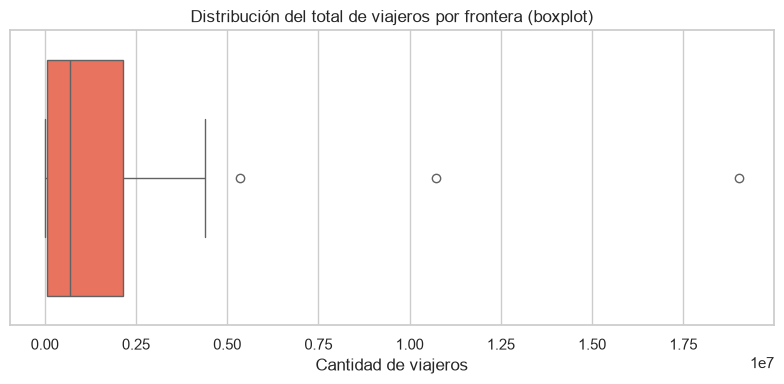

In [13]:
# Outliers sobre el total de viajeros agregado por frontera (sum, no conteo de filas)
if "Frontera" in df.columns:
    conteo_frontera = df.groupby("Frontera")[VIAJEROS_COL].sum().sort_values(ascending=False)
    stats = resumen_outliers_iqr(conteo_frontera)
    print("Outliers en el total de viajeros por frontera:", stats)

    plt.figure(figsize=(8, 4))
    sns.boxplot(x=conteo_frontera.values, color="tomato")
    plt.title("Distribución del total de viajeros por frontera (boxplot)")
    plt.xlabel("Cantidad de viajeros")
    plt.tight_layout()
    plt.show()


**Interpretación (completar tras ejecutar):** señala si existen fronteras o países
con volúmenes extremadamente altos/bajos respecto al resto, y si estos atípicos son
esperables (ej. un puesto fronterizo principal) o requieren revisión de calidad de datos.

## 7. Comportamiento temporal del número de viajeros

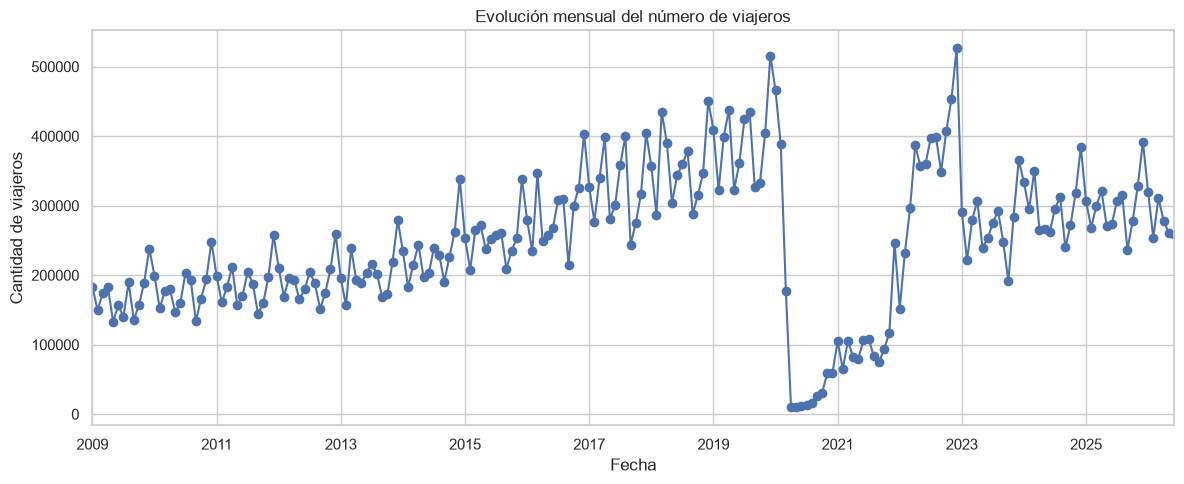

count       210.000000
mean     248990.176637
std      100744.492958
min        9779.000000
25%      184592.862436
50%      250393.500000
75%      315372.811698
max      526190.000000
Name: Viajero, dtype: float64


In [14]:
if df["fecha_dt"].notna().any():
    serie_temporal = df.groupby(df["fecha_dt"].dt.to_period("M"))[VIAJEROS_COL].sum()
    serie_temporal.index = serie_temporal.index.to_timestamp()

    plt.figure(figsize=(12, 5))
    serie_temporal.plot(marker="o")
    plt.title("Evolución mensual del número de viajeros")
    plt.xlabel("Fecha")
    plt.ylabel("Cantidad de viajeros")
    plt.tight_layout()
    plt.show()

    print(serie_temporal.describe())
else:
    print("No hay columna temporal disponible. Define DATE_COL o YEAR_COL/MONTH_COL "
          "en la configuración para generar este análisis.")


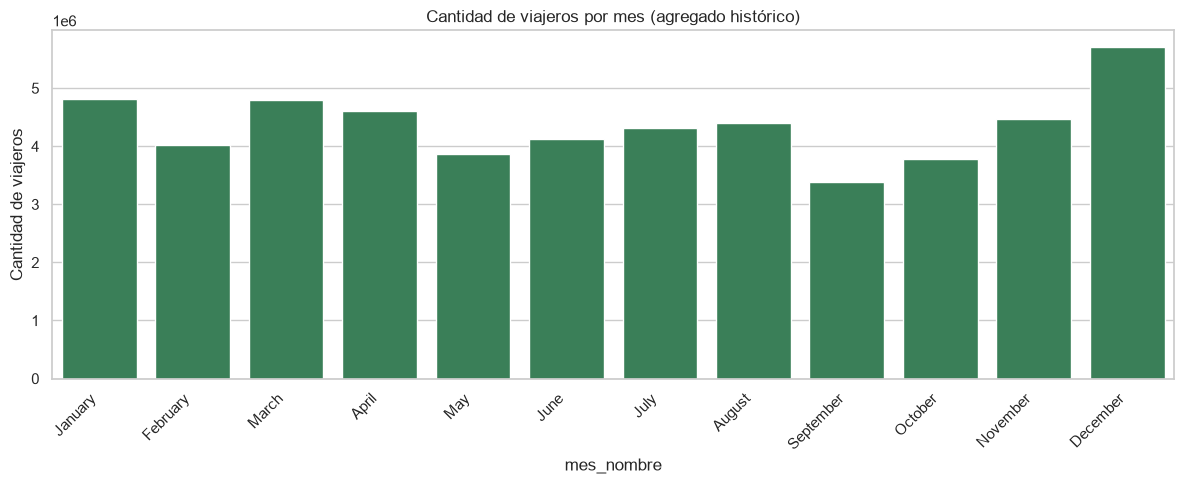

In [15]:
# Estacionalidad por mes (si hay suficientes datos)
if df["fecha_dt"].notna().any():
    df["mes_nombre"] = df["fecha_dt"].dt.month_name()
    orden_meses = ["January","February","March","April","May","June",
                   "July","August","September","October","November","December"]
    conteo_mes = df.groupby("mes_nombre")[VIAJEROS_COL].sum().reindex(orden_meses)

    plt.figure(figsize=(12, 5))
    sns.barplot(x=conteo_mes.index, y=conteo_mes.values, color="seagreen")
    plt.xticks(rotation=45, ha="right")
    plt.title("Cantidad de viajeros por mes (agregado histórico)")
    plt.ylabel("Cantidad de viajeros")
    plt.tight_layout()
    plt.show()


**Interpretación (completar tras ejecutar):** describe tendencia (crecimiento/decrecimiento),
estacionalidad (meses pico como vacaciones o fiestas) y posibles quiebres (ej. pandemia,
cierres de frontera).

> **Nota sobre la caída de 2023:** entre 2022 y 2023 la categoría "Viajero" (dentro de
> `Tipo de Viajero`) cambia de definición y excluye viajeros no turísticos de alta frecuencia
> (comercio fronterizo, tránsito). Esto hace parecer que el total cae fuertemente en 2023, pero
> no es una caída real de turismo. Para comparaciones consistentes en todo el período (y para
> las series de tiempo del punto 3) se debe usar **Turista + Excursionista**.

## 8. Países con mayor cantidad de viajeros

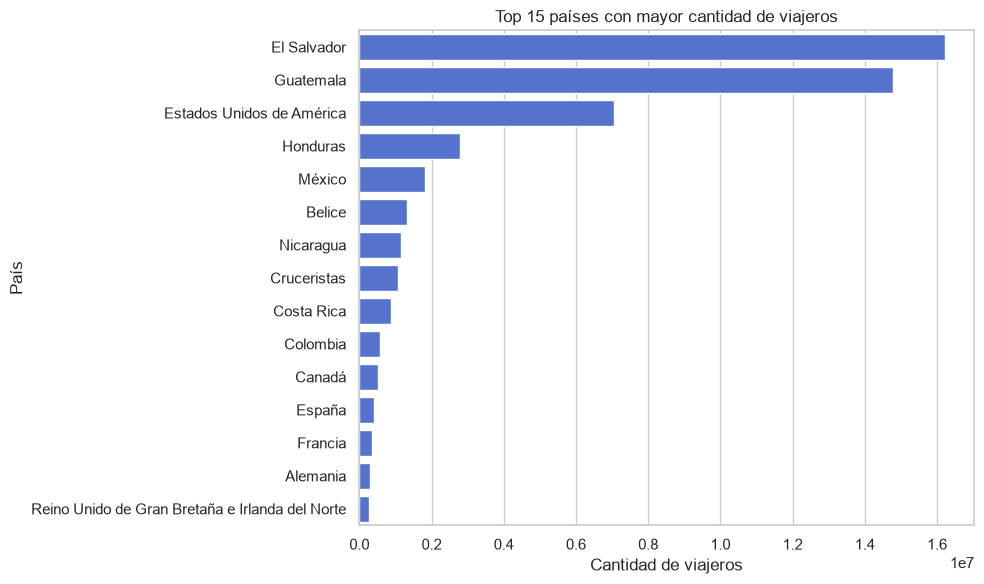

País
El Salvador                                        1.621398e+07
Guatemala                                          1.479233e+07
Estados Unidos de América                          7.047843e+06
Honduras                                           2.788233e+06
México                                             1.808946e+06
Belice                                             1.328256e+06
Nicaragua                                          1.164343e+06
Cruceristas                                        1.078372e+06
Costa Rica                                         8.821797e+05
Colombia                                           5.610353e+05
Canadá                                             5.262466e+05
España                                             3.955236e+05
Francia                                            3.382281e+05
Alemania                                           3.004004e+05
Reino Unido de Gran Bretaña e Irlanda del Norte    2.713677e+05
Name: Viajero, dtype: float64

In [16]:
top_paises = df.groupby("País")[VIAJEROS_COL].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_paises.values, y=top_paises.index, color="royalblue")
plt.title("Top 15 países con mayor cantidad de viajeros")
plt.xlabel("Cantidad de viajeros")
plt.tight_layout()
plt.show()

top_paises


**Interpretación (completar tras ejecutar):** identifica los países emisores dominantes
y si hay concentración (pocos países explican la mayoría del flujo) o diversificación.

## 9. Regiones con mayor cantidad de viajeros

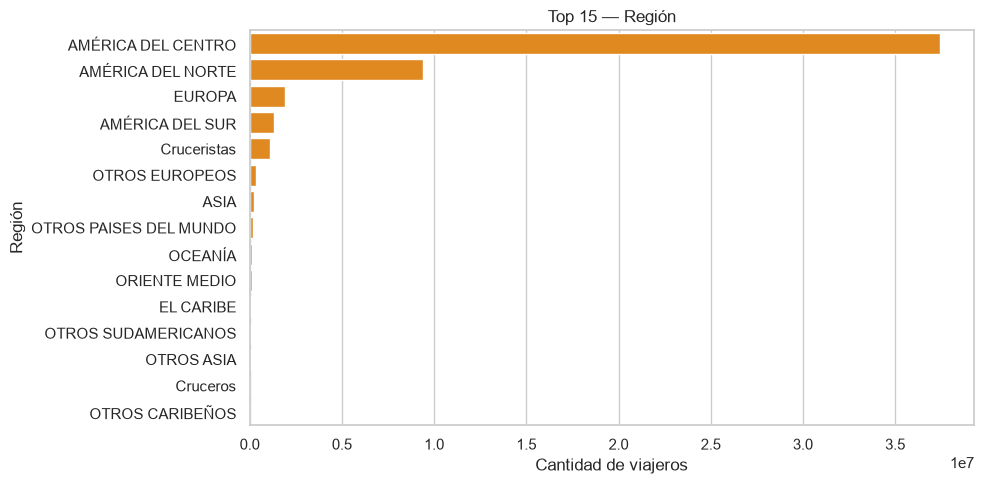

Región
AMÉRICA DEL CENTRO        3.740653e+07
AMÉRICA DEL NORTE         9.383035e+06
EUROPA                    1.906163e+06
AMÉRICA DEL SUR           1.300422e+06
Cruceristas               1.078372e+06
OTROS EUROPEOS            3.164575e+05
ASIA                      2.432984e+05
OTROS PAISES DEL MUNDO    1.560021e+05
OCEANÍA                   1.350359e+05
ORIENTE MEDIO             1.276261e+05
EL CARIBE                 7.747633e+04
OTROS SUDAMERICANOS       4.798459e+04
OTROS ASIA                4.758712e+04
Cruceros                  2.603000e+04
OTROS CARIBEÑOS           2.281392e+04
Name: Viajero, dtype: float64 



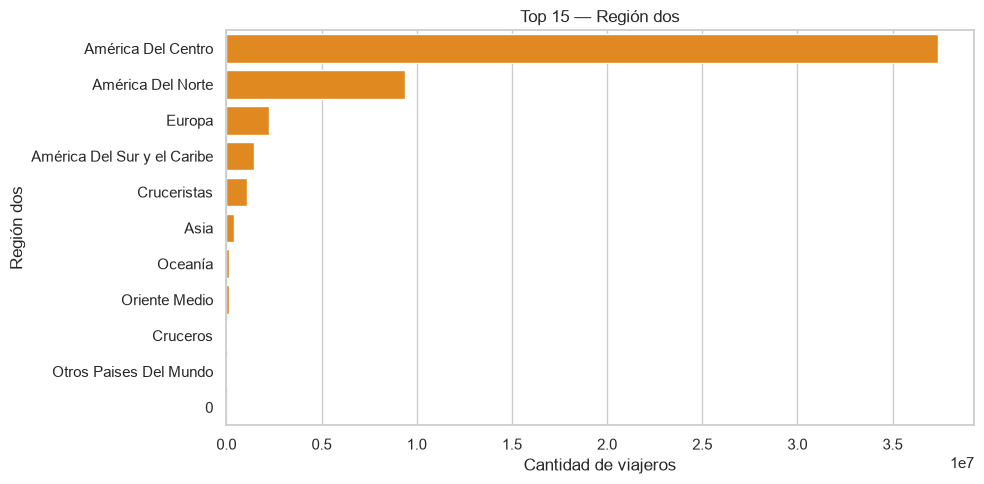

Región dos
América Del Centro             3.740653e+07
América Del Norte              9.383035e+06
Europa                         2.222621e+06
América Del Sur y el Caribe    1.447950e+06
Cruceristas                    1.078372e+06
Asia                           4.217025e+05
Oceanía                        1.400472e+05
Oriente Medio                  1.357125e+05
Cruceros                       2.603000e+04
Otros Paises Del Mundo         2.511115e+04
0                              8.210000e+02
Name: Viajero, dtype: float64 



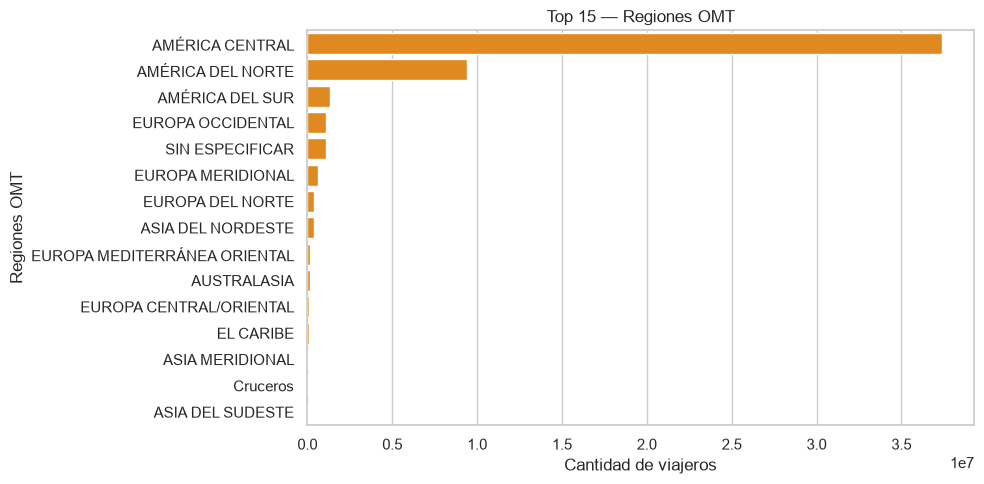

Regiones OMT
AMÉRICA CENTRAL                 3.740653e+07
AMÉRICA DEL NORTE               9.383066e+06
AMÉRICA DEL SUR                 1.348406e+06
EUROPA OCCIDENTAL               1.088278e+06
SIN ESPECIFICAR                 1.078372e+06
EUROPA MERIDIONAL               6.195133e+05
EUROPA DEL NORTE                3.898756e+05
ASIA DEL NORDESTE               3.752774e+05
EUROPA MEDITERRÁNEA ORIENTAL    1.352310e+05
AUSTRALASIA                     1.350359e+05
EUROPA CENTRAL/ORIENTAL         1.173690e+05
EL CARIBE                       1.004957e+05
ASIA MERIDIONAL                 3.006878e+04
Cruceros                        2.603000e+04
ASIA DEL SUDESTE                1.643505e+04
Name: Viajero, dtype: float64 



In [17]:
for col_region in ["Región", "Región dos", "Regiones OMT"]:
    if col_region in df.columns:
        top_region = df.groupby(col_region)[VIAJEROS_COL].sum().sort_values(ascending=False).head(15)
        plt.figure(figsize=(10, 5))
        sns.barplot(x=top_region.values, y=top_region.index, color="darkorange")
        plt.title(f"Top 15 — {col_region}")
        plt.xlabel("Cantidad de viajeros")
        plt.tight_layout()
        plt.show()
        print(top_region, "\n")


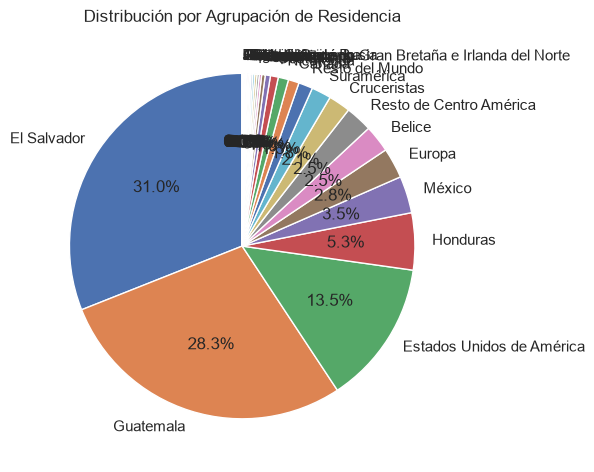

In [18]:
# Agrupación de residencia (ej. residentes vs no residentes)
if "Agrupación Residencia" in df.columns:
    agrup = df.groupby("Agrupación Residencia")[VIAJEROS_COL].sum().sort_values(ascending=False)
    plt.figure(figsize=(6, 6))
    plt.pie(agrup.values, labels=agrup.index, autopct="%1.1f%%", startangle=90)
    plt.title("Distribución por Agrupación de Residencia")
    plt.tight_layout()
    plt.show()


**Interpretación (completar tras ejecutar):** compara la granularidad de `Región`,
`Región dos` y `Regiones OMT`, y describe qué agrupación resulta más útil para reportes
(más agregada vs. más detallada).

## 10. Vías de ingreso y fronteras más utilizadas

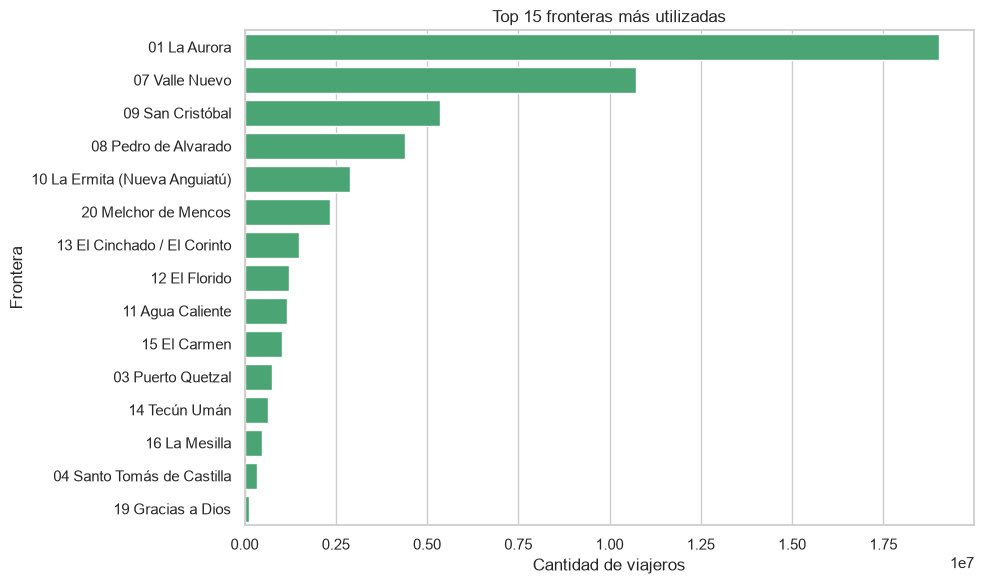

Frontera
01 La Aurora                     1.903440e+07
07 Valle Nuevo                   1.073234e+07
09 San Cristóbal                 5.363009e+06
08 Pedro de Alvarado             4.393577e+06
10 La Ermita (Nueva Anguiatú)    2.879210e+06
20 Melchor de Mencos             2.349551e+06
13 El Cinchado / El Corinto      1.497006e+06
12 El Florido                    1.221040e+06
11 Agua Caliente                 1.154542e+06
15 El Carmen                     1.023092e+06
03 Puerto Quetzal                7.415156e+05
14 Tecún Umán                    6.553718e+05
16 La Mesilla                    4.718493e+05
04 Santo Tomás de Castilla       3.473774e+05
19 Gracias a Dios                1.231049e+05
Name: Viajero, dtype: float64

In [19]:
top_frontera = df.groupby("Frontera")[VIAJEROS_COL].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_frontera.values, y=top_frontera.index, color="mediumseagreen")
plt.title("Top 15 fronteras más utilizadas")
plt.xlabel("Cantidad de viajeros")
plt.tight_layout()
plt.show()

top_frontera


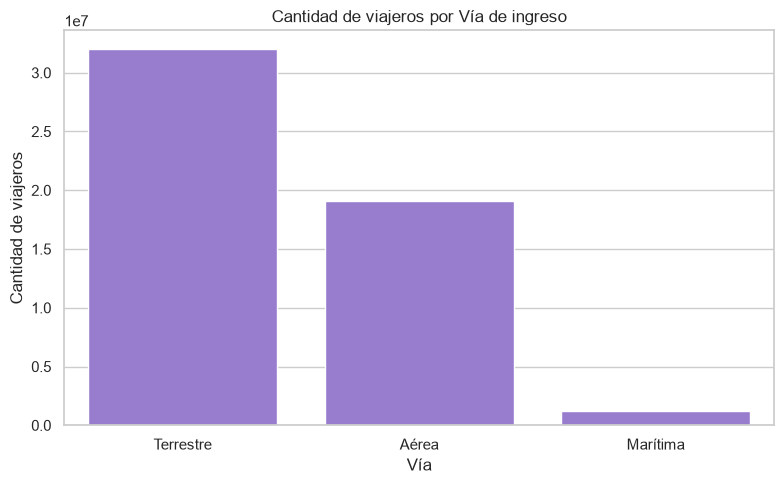

Vía
Terrestre    3.199530e+07
Aérea        1.906385e+07
Marítima     1.228782e+06
Name: Viajero, dtype: float64


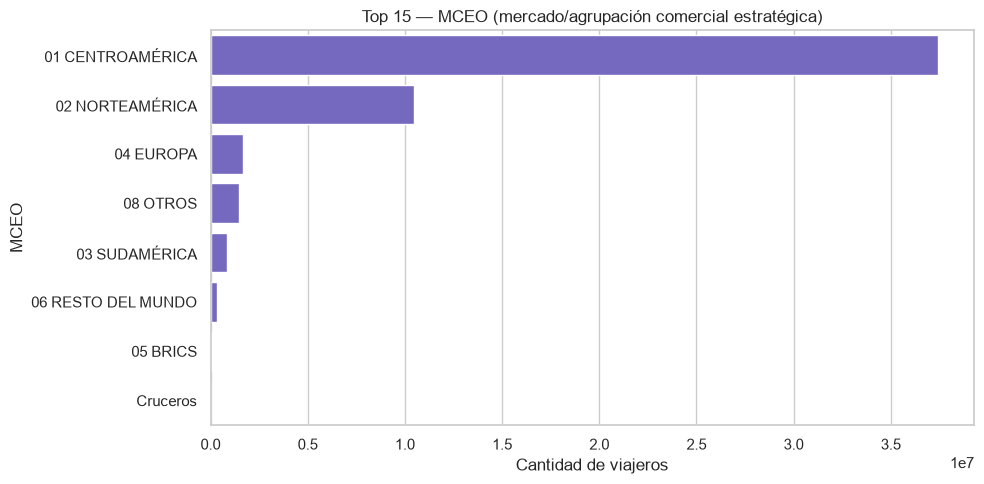

MCEO
01 CENTROAMÉRICA      3.740653e+07
02 NORTEAMÉRICA       1.046141e+07
04 EUROPA             1.666321e+06
08 OTROS              1.453527e+06
03 SUDAMÉRICA         8.676292e+05
06 RESTO DEL MUNDO    3.104315e+05
05 BRICS              9.605627e+04
Cruceros              2.603000e+04
Name: Viajero, dtype: float64


In [20]:
# Vía de ingreso (Aérea, Terrestre, Marítima) — variable distinta de MCEO
if "Vía" in df.columns:
    top_via = df.groupby("Vía")[VIAJEROS_COL].sum().sort_values(ascending=False)
    plt.figure(figsize=(8, 5))
    sns.barplot(x=top_via.index, y=top_via.values, color="mediumpurple")
    plt.title("Cantidad de viajeros por Vía de ingreso")
    plt.ylabel("Cantidad de viajeros")
    plt.tight_layout()
    plt.show()
    print(top_via)

# MCEO: mercado/agrupación comercial estratégica (clasificación de mercados objetivo),
# NO es la vía de ingreso — se analiza aparte.
if "MCEO" in df.columns:
    top_mceo = df.groupby("MCEO")[VIAJEROS_COL].sum().sort_values(ascending=False).head(15)
    plt.figure(figsize=(10, 5))
    sns.barplot(x=top_mceo.values, y=top_mceo.index, color="slateblue")
    plt.title("Top 15 — MCEO (mercado/agrupación comercial estratégica)")
    plt.xlabel("Cantidad de viajeros")
    plt.tight_layout()
    plt.show()
    print(top_mceo)


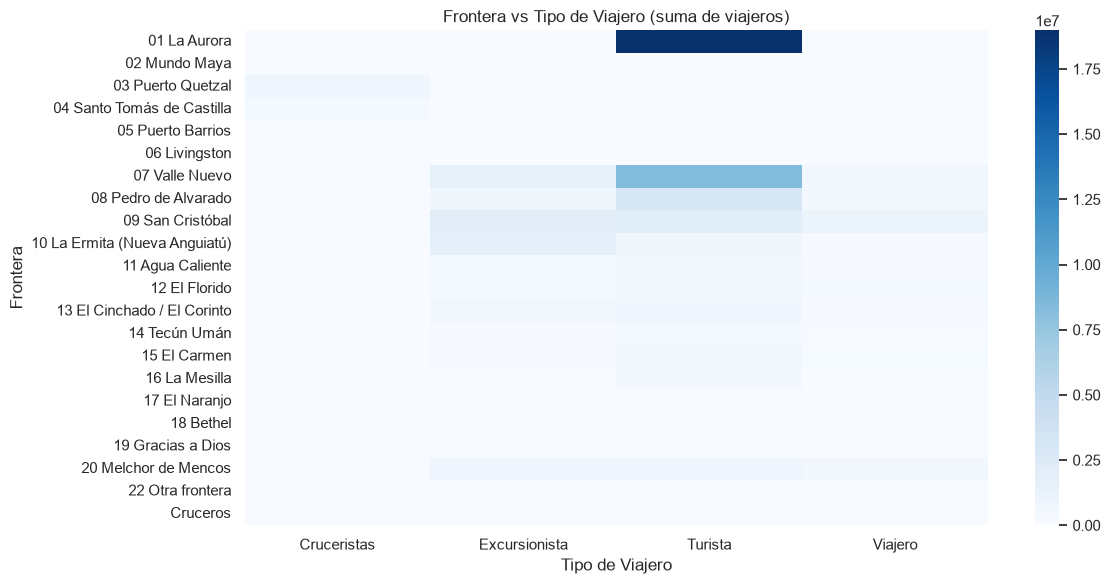

In [21]:
# Cruce Frontera x Tipo de Viajero (suma de viajeros, no conteo de filas)
if "Tipo de Viajero" in df.columns:
    cruce = df.pivot_table(index="Frontera", columns="Tipo de Viajero",
                            values=VIAJEROS_COL, aggfunc="sum", fill_value=0)
    plt.figure(figsize=(12, 6))
    sns.heatmap(cruce, cmap="Blues", annot=False)
    plt.title("Frontera vs Tipo de Viajero (suma de viajeros)")
    plt.tight_layout()
    plt.show()


**Interpretación (completar tras ejecutar):** identifica cuáles son las fronteras/vías
de ingreso dominantes, si existe especialización por tipo de viajero (ej. turistas vs.
transfronterizos) en fronteras específicas.

## 11. Estadísticas descriptivas generales

In [22]:
cat_cols = [c for c in ["Frontera", "País", "Región", "Región dos", "Regiones OMT",
                         "MCEO", "Agrupación Residencia", "Tipo de Viajero"] if c in df.columns]

def categoria_dominante(col):
    sumas = df.groupby(col)[VIAJEROS_COL].sum()
    return sumas.idxmax(), sumas.max()

dominantes = {c: categoria_dominante(c) for c in cat_cols}
resumen_categoricas = pd.DataFrame({
    "n_categorias_unicas": df[cat_cols].nunique(),
    "categoria_con_mas_viajeros": {c: v[0] for c, v in dominantes.items()},
    "viajeros_categoria_dominante": {c: v[1] for c, v in dominantes.items()},
})
resumen_categoricas


,n_categorias_unicas,categoria_con_mas_viajeros,viajeros_categoria_dominante
Frontera,22,01 La Aurora,1.903440e+07
País,235,El Salvador,1.621398e+07
Región,17,AMÉRICA DEL CENTRO,3.740653e+07
Región dos,11,América Del Centro,3.740653e+07
Regiones OMT,26,AMÉRICA CENTRAL,3.740653e+07
MCEO,8,01 CENTROAMÉRICA,3.740653e+07
Agrupación Residencia,33,El Salvador,1.621398e+07
Tipo de Viajero,4,Turista,3.764273e+07


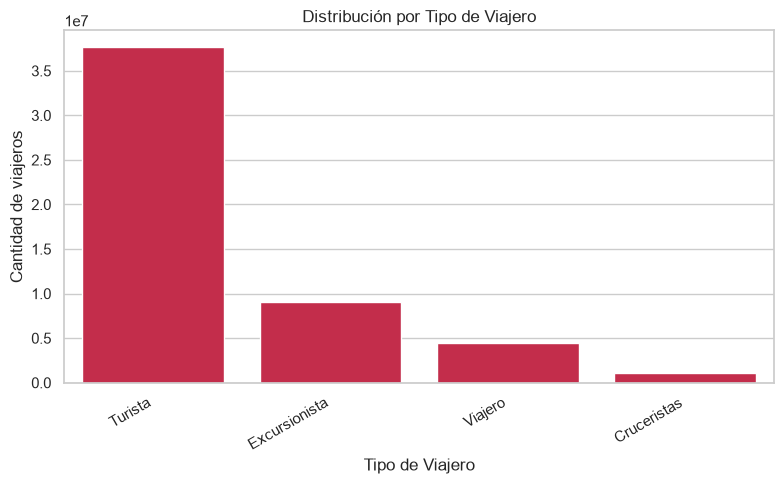

Tipo de Viajero
Turista          3.764273e+07
Excursionista    9.069184e+06
Viajero          4.471622e+06
Cruceristas      1.104402e+06
Name: Viajero, dtype: float64


In [23]:
# Distribución de Tipo de Viajero
if "Tipo de Viajero" in df.columns:
    tipo_viajero = df.groupby("Tipo de Viajero")[VIAJEROS_COL].sum().sort_values(ascending=False)
    plt.figure(figsize=(8, 5))
    sns.barplot(x=tipo_viajero.index, y=tipo_viajero.values, color="crimson")
    plt.xticks(rotation=30, ha="right")
    plt.title("Distribución por Tipo de Viajero")
    plt.ylabel("Cantidad de viajeros")
    plt.tight_layout()
    plt.show()
    print(tipo_viajero)


**Interpretación final (completar tras ejecutar):** sintetiza los hallazgos principales:
tendencia temporal, concentración geográfica (países/regiones), fronteras dominantes,
calidad de los datos (faltantes/duplicados/atípicos) y cualquier recomendación para el
preprocesamiento previo a un modelo o reporte posterior.